# Multi-GPU Lattice Boltzmann: local collision, neighbour communication

This worked example simulates a **decaying periodic shear wave** with the D2Q9
Lattice Boltzmann method (LBM). The physics is deliberately small: an isothermal,
weakly compressible fluid, no walls, no forcing, and one relaxation time. The
implementation is the lesson: distribute spatial slabs, compute locally, exchange
only the populations that cross a device boundary, and keep the time loop compiled.

After this notebook you should be able to explain the ownership of each array,
trace a diagonal population across a slab boundary, test communication independently
of the physics, and measure strong scaling without timing compilation or transfers.

**Prerequisites:** NumPy array indexing, basic JAX `jit` and sharding concepts
(see `jax_features.ipynb`), and the supplied JAX environment. No fluid-mechanics
background is assumed. Allow about 45–60 minutes for the worked example, including
questions and setup; the optional exercises form a separate 25–35 minute block.

**Setup:** use `environment.yml` in this directory, activate `python_on_gpus_jax`,
then start `jupyter lab`. This notebook uses one Python process on one node and
at least two visible devices. For a correctness run without GPUs, start Jupyter with
`JAX_MULTI_DEVICE_CPU_EMULATION=1 jupyter lab`. Restart the kernel before changing
device configuration. Emulated CPU devices test communication semantics; their
timings do not predict GPU performance. Modern `jax.shard_map` is required.

Small text and plot outputs are intentionally retained for static reading.
The optional GPU benchmark is disabled by default.

## 1. Nine populations per cell

The state is `f[x, y, q]`, with shape $(N_x,N_y,9)$. Here $N_x$ and $N_y$ are
the numbers of lattice sites, and $q=0,\ldots,8$ labels a direction. D2Q9 means
two spatial dimensions and nine discrete velocities $\mathbf{c}_q$:

```text
  6 ↖  2 ↑  5 ↗        y increases upwards
  3 ←  0 •  1 →        x increases to the right
  7 ↙  4 ↓  8 ↘
```

Each population $f_q$ is a directional density, rather than an individual
particle. All lengths and times use lattice units: the spacing and time step
are both one. The local density $\rho$ and velocity $\mathbf{u}$ follow from

$$\rho=\sum_q f_q,\qquad \rho\mathbf{u}=\sum_q f_q\mathbf{c}_q.$$

The equilibrium weights $w_q$ are $4/9$ for rest, $1/9$ for axial directions,
and $1/36$ for diagonals. A local collision relaxes populations towards equilibrium:

$$f_q^{\mathrm{eq}}=w_q\rho\left[1+3\mathbf{c}_q\cdot\mathbf{u}
+\frac{9}{2}(\mathbf{c}_q\cdot\mathbf{u})^2-\frac{3}{2}\mathbf{u}\cdot\mathbf{u}\right],$$
$$f_q^*=f_q+\frac{f_q^{\mathrm{eq}}-f_q}{\tau}.$$

Here $f_q^*$ is the post-collision population and $\tau$ is the BGK relaxation
time. Streaming then moves that population by exactly one discrete velocity:

$$f_q(\mathbf{x},t+1)=f_q^*(\mathbf{x}-\mathbf{c}_q,t).$$

The position $\mathbf{x}=(x,y)$ is a lattice site and $t$ is the step count.
This is a **pull** interpretation: each destination reads its upstream source.
Collision needs only the current cell; streaming needs neighbours.

The kinematic viscosity is $\nu=(\tau-1/2)/3$ and the sound speed is
$c_s=1/\sqrt{3}$. We choose $\tau=0.8$ and a small velocity amplitude
$U=0.03$, so the initial Mach number $U/c_s$ is about 0.052. Positive viscosity
requires $\tau>1/2$, but that condition alone does not guarantee stability.

In [1]:
import os
import time
from functools import partial

import jax

EMULATE_CPU_DEVICES = os.environ.get("JAX_MULTI_DEVICE_CPU_EMULATION", "0") == "1"
if EMULATE_CPU_DEVICES:
    jax.config.update("jax_platform_name", "cpu")
    jax.config.update("jax_num_cpu_devices", 4)

# float32 is the throughput-oriented default; float64 is useful for validation.
USE_X64 = os.environ.get("JAX_ENABLE_X64", "0") == "1"
jax.config.update("jax_enable_x64", USE_X64)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from jax import lax
from jax.sharding import Mesh, NamedSharding, PartitionSpec as P

devices = jax.local_devices()
if jax.process_count() != 1:
    raise RuntimeError("This notebook assumes one process on one node.")
if len(devices) < 2:
    raise RuntimeError(
        "At least two devices are needed. Restart Jupyter with "
        "JAX_MULTI_DEVICE_CPU_EMULATION=1 for CPU correctness testing."
    )

DTYPE = np.float64 if USE_X64 else np.float32
AXIS = "slabs"
C = ((0, 0), (1, 0), (0, 1), (-1, 0), (0, -1),
     (1, 1), (-1, 1), (-1, -1), (1, -1))
CX = jnp.asarray([cx for cx, cy in C], dtype=DTYPE)
CY = jnp.asarray([cy for cx, cy in C], dtype=DTYPE)
W = jnp.asarray([4/9, 1/9, 1/9, 1/9, 1/9, 1/36, 1/36, 1/36, 1/36], dtype=DTYPE)
POS_X = (1, 5, 8)
NEG_X = (3, 6, 7)

TAU = 0.8
NU = (TAU - 0.5) / 3.0
U = 0.03
assert TAU > 0.5

print(f"JAX {jax.__version__}; backend {jax.default_backend()}; dtype {DTYPE.__name__}")
print(f"Devices: {devices}")
print(f"Viscosity: {NU:.3f}; initial Mach number: {U * np.sqrt(3):.3f}")

JAX 0.10.2; backend cpu; dtype float32
Devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Viscosity: 0.100; initial Mach number: 0.052


## 2. The local calculation and a single-device reference

The population dimension is kept intact on every device. Broadcasting evaluates
the equilibrium for all cells; `jit` can fuse local array operations. The small
Python loop over nine fixed directions is unrolled during tracing. The reference
streamer rolls a **global, unsharded** domain periodically in both directions.
Later we will give the distributed implementation the same collision function,
but a different streamer.

In [2]:
def macroscopic(f):
    rho = jnp.sum(f, axis=-1)
    ux = jnp.sum(f * CX, axis=-1) / rho
    uy = jnp.sum(f * CY, axis=-1) / rho
    return rho, ux, uy


def equilibrium(rho, ux, uy):
    cu = ux[..., None] * CX + uy[..., None] * CY
    u2 = ux**2 + uy**2
    return rho[..., None] * W * (1.0 + 3.0 * cu + 4.5 * cu**2 - 1.5 * u2[..., None])


def collide(f):
    return f + (equilibrium(*macroscopic(f)) - f) / TAU


def stream_periodic(f_post):
    return jnp.stack([
        jnp.roll(f_post[..., q], shift=(cx, cy), axis=(0, 1))
        for q, (cx, cy) in enumerate(C)
    ], axis=-1)


def reference_step(f):
    return stream_periodic(collide(f))


def build_solver(step):
    @jax.jit
    def solve(f, n_steps):
        return lax.fori_loop(0, n_steps, lambda _, state: step(state), f)
    return solve


reference_solve = build_solver(reference_step)

## 3. Divide space and exchange only outgoing populations

Let $D$ be the device count. Each device owns $L=N_x/D$ consecutive $x$ rows,
all $N_y$ sites in $y$, and all nine populations. Require $N_x$ to be divisible
by $D$. `PartitionSpec("slabs", None, None)` splits only the first dimension.
Inside `shard_map`, the array has local shape $(L,N_y,9)$.

```text
      global periodic x domain
  [ slab 0 ] [ slab 1 ] ... [ slab D-1 ]
     last row: q=1,5,8  → next slab's first row
     first row: q=3,6,7 ← previous slab's last row
     first and last slabs are also neighbours
```

We exchange **post-collision** values, because streaming transports $f^*$.
One `ppermute` sends the last row's three positive-$x$ populations to the next
slab. A second sends the first row's three negative-$x$ populations to the
previous slab. Both messages have shape $(N_y,3)$. Every device sends
$6N_yb$ bytes per step, where $b$ is the bytes per scalar, and receives the
same payload. There is no population exchange for $c_{qx}=0$.

For a diagonal population, the received row still needs its periodic $y$ shift.
We first repair the $x$ boundary of a local roll, then roll in $y$. Rolling in
$y$ is local because each slab owns the entire $y$ dimension.
`ppermute` pairs are `(source, destination)`; the two-device case alone cannot
distinguish the two ring directions, which is why four-device testing matters.

In [3]:
def make_distributed_operators(mesh):
    send_right = tuple((p, (p + 1) % mesh.size) for p in range(mesh.size))
    send_left = tuple((p, (p - 1) % mesh.size) for p in range(mesh.size))
    f_spec = P(AXIS, None, None)

    @partial(jax.shard_map, mesh=mesh, in_specs=f_spec, out_specs=f_spec,
             axis_names={AXIS})
    def stream(f_post):
        # jnp.take keeps the packed message dimension explicit: (Ny, 3).
        from_left = lax.ppermute(
            jnp.take(f_post[-1], jnp.asarray(POS_X), axis=-1), AXIS, send_right
        )
        from_right = lax.ppermute(
            jnp.take(f_post[0], jnp.asarray(NEG_X), axis=-1), AXIS, send_left
        )

        populations = []
        for q, (cx, cy) in enumerate(C):
            shifted = jnp.roll(f_post[..., q], cx, axis=0)
            if cx == 1:
                shifted = shifted.at[0].set(from_left[:, POS_X.index(q)])
            elif cx == -1:
                shifted = shifted.at[-1].set(from_right[:, NEG_X.index(q)])
            populations.append(jnp.roll(shifted, cy, axis=1))
        return jnp.stack(populations, axis=-1)

    @partial(jax.shard_map, mesh=mesh, in_specs=f_spec, out_specs=P(),
             axis_names={AXIS})
    def totals(f):
        rho, ux, uy = macroscopic(f)
        local = jnp.stack((jnp.sum(rho), jnp.sum(rho * ux),
                           jnp.sum(rho * uy), 0.5 * jnp.sum(rho * (ux**2 + uy**2))))
        return lax.psum(local, AXIS)

    def step(f):
        return stream(collide(f))

    return jax.jit(stream), jax.jit(totals), build_solver(step)


mesh = Mesh(np.asarray(devices), (AXIS,))
f_sharding = NamedSharding(mesh, P(AXIS, None, None))
distributed_stream, distributed_totals, distributed_solve = make_distributed_operators(mesh)

## 4. Test streaming before running fluid physics

A shear wave is uniform in $y$, so it cannot reveal a missing diagonal $y$
shift. Instead, label **every site and direction** with a distinct value and
compare the streamed result with independent NumPy indexing of upstream sites.
This tests all directions, internal interfaces, and the global periodic seam.
Also test one-row slabs, where every positive/negative-$x$ source is remote.
These labels are routing-test data, not physically meaningful fluid populations.

In [4]:
def check_streaming(nx, ny):
    tags = np.arange(nx * ny * 9, dtype=DTYPE).reshape(nx, ny, 9)
    x = np.arange(nx)[:, None]
    y = np.arange(ny)[None, :]
    expected = np.stack([
        tags[(x - cx) % nx, (y - cy) % ny, q]
        for q, (cx, cy) in enumerate(C)
    ], axis=-1)
    actual = np.asarray(distributed_stream(jax.device_put(tags, f_sharding)))
    np.testing.assert_array_equal(actual, expected)
    print(f"All nine streaming directions passed on {nx} x {ny} sites.")


check_streaming(3 * mesh.size, 7)
check_streaming(mesh.size, 5)

# Equilibrium moments and collision conservation are independent local checks.
rng = np.random.default_rng(2026)
rho_test = jnp.asarray(rng.uniform(0.95, 1.05, (8, 7)), dtype=DTYPE)
ux_test = jnp.asarray(rng.uniform(-0.02, 0.02, (8, 7)), dtype=DTYPE)
uy_test = jnp.asarray(rng.uniform(-0.02, 0.02, (8, 7)), dtype=DTYPE)
moment_tol = 1e-12 if USE_X64 else 3e-7
f_test = equilibrium(rho_test, ux_test, uy_test)
for actual, expected in zip(macroscopic(f_test), (rho_test, ux_test, uy_test)):
    np.testing.assert_allclose(actual, expected, rtol=moment_tol, atol=moment_tol)
def moments(f):
    return jnp.stack((jnp.sum(f, axis=-1), jnp.sum(f * CX, axis=-1),
                      jnp.sum(f * CY, axis=-1)), axis=-1)
f_noneq = f_test + jnp.asarray(rng.uniform(-1e-4, 1e-4, f_test.shape), dtype=DTYPE)
np.testing.assert_allclose(moments(collide(f_noneq)), moments(f_noneq),
                           rtol=moment_tol, atol=moment_tol)
print("Equilibrium moments and local collision conservation passed.")

All nine streaming directions passed on 12 x 7 sites.
All nine streaming directions passed on 4 x 5 sites.


Equilibrium moments and local collision conservation passed.


## 5. Initialize a shear wave

The initial velocity is $u_x=0$ and $u_y=U\sin(kx)$, with density $\rho=1$.
The wave number is $k=2\pi/N_x$. In the incompressible continuum limit it decays as

$$u_y(x,t)=U\sin(kx)\exp(-\nu k^2t),\qquad
E(t)/E(0)=\exp(-2\nu k^2t),$$

where $E=\tfrac12\sum_{x,y}\rho(u_x^2+u_y^2)$ is total kinetic energy.
Advection vanishes for this particular flow: velocity points along $y$ and
depends only on $x$. Viscosity smooths the bands. This avoids pressure-boundary
conditions and a turbulence model. It is a full 2-D implementation, although
the demonstration solution varies in only one coordinate.

We start with equilibrium populations. Their initial non-equilibrium viscous
stress has not yet developed, so expect a small startup transient as well as
lattice discretization error. The continuum curve is an approximate physical
check, not an exact oracle for the finite-grid LBM result.

In [5]:
NX, NY = 64, 96
N_STEPS = 600
SAMPLE_EVERY = 30
if NX % mesh.size:
    raise ValueError(f"NX={NX} must be divisible by {mesh.size} devices.")
K = 2 * np.pi / NX


def shear_initial(nx, ny):
    x = jnp.arange(nx, dtype=DTYPE)[:, None]
    rho = jnp.ones((nx, ny), dtype=DTYPE)
    ux = jnp.zeros_like(rho)
    uy = jnp.broadcast_to(U * jnp.sin(2 * jnp.pi * x / nx), rho.shape)
    return equilibrium(rho, ux, uy)


# This tiny global initialization and reference live on just one device.
# Large production cases should initialize each shard directly.
single_sharding = jax.sharding.SingleDeviceSharding(devices[0])
with jax.default_device(devices[0]):
    f0_reference = jax.device_put(shear_initial(NX, NY), single_sharding)
f0 = jax.device_put(f0_reference, f_sharding)
print(f"Global shape: {f0.shape}; partition: {f0.sharding.spec}")
for shard in f0.addressable_shards:
    print(f"{shard.device}: x rows {shard.index[0]}, shape {shard.data.shape}")
print(f"Sent payload per device per step: {6 * NY * np.dtype(DTYPE).itemsize} bytes")

Global shape: (64, 96, 9); partition: P('slabs', None, None)
cpu:0: x rows slice(0, 16, None), shape (16, 96, 9)
cpu:1: x rows slice(16, 32, None), shape (16, 96, 9)
cpu:2: x rows slice(32, 48, None), shape (16, 96, 9)
cpu:3: x rows slice(48, 64, None), shape (16, 96, 9)
Sent payload per device per step: 2304 bytes


## 6. Evolve sharded populations; reduce small diagnostics

`lax.fori_loop` advances the state on devices. There is no population transfer
through Python or the host in the time loop. For plotting we pause every 30 steps
and use `psum` to reduce mass, two momentum components, and energy to four scalars.
The diagnostic collective is separate from the two streaming exchanges per step.
We retain only those scalar samples, rather than a history of all populations.

The single-device reference shares the collision formula, so agreement primarily
checks the decomposition. Equilibrium moments, conservation, and the expected
viscous decay provide complementary numerical checks.

In [6]:
f = f0
sample_times = [0]
sample_totals = [np.asarray(distributed_totals(f))]
for start in range(0, N_STEPS, SAMPLE_EVERY):
    chunk = min(SAMPLE_EVERY, N_STEPS - start)
    f = distributed_solve(f, chunk)
    sample_times.append(start + chunk)
    sample_totals.append(np.asarray(distributed_totals(f)))

f_reference = reference_solve(f0_reference, N_STEPS)
f_reference.block_until_ready()
f_host = np.asarray(f)  # One small final gather for validation and plotting.
reference_error = float(np.max(np.abs(f_host - np.asarray(f_reference))))
sample_times = np.asarray(sample_times)
sample_totals = np.asarray(sample_totals, dtype=np.float64)
relative_mass_drift = float(np.max(np.abs(sample_totals[:, 0] / sample_totals[0, 0] - 1)))
momentum_drift_per_site = float(np.max(np.abs(
    sample_totals[:, 1:3] - sample_totals[0, 1:3]
)) / (NX * NY))
energy_ratio = sample_totals[:, 3] / sample_totals[0, 3]
expected_energy_ratio = np.exp(-2 * NU * K**2 * sample_times)
energy_curve_error = float(np.max(np.abs(energy_ratio - expected_energy_ratio)))
rho_host = f_host.sum(axis=-1)
ux_host = (f_host * np.asarray(CX)).sum(axis=-1) / rho_host
uy_host = (f_host * np.asarray(CY)).sum(axis=-1) / rho_host
expected_uy = U * np.sin(K * np.arange(NX)) * np.exp(-NU * K**2 * N_STEPS)
velocity_error_relative_to_U = float(np.max(np.abs(uy_host - expected_uy[:, None])) / U)

print(f"Maximum population difference from single device: {reference_error:.3e}")
print(f"Maximum relative mass drift: {relative_mass_drift:.3e}")
print(f"Maximum momentum drift per site: {momentum_drift_per_site:.3e}")
print(f"Maximum energy-ratio error from continuum curve: {energy_curve_error:.3e}")
print(f"Final velocity error / initial amplitude: {velocity_error_relative_to_U:.3e}")
print(f"Final population partition: {f.sharding.spec}")

Maximum population difference from single device: 0.000e+00
Maximum relative mass drift: 1.589e-06
Maximum momentum drift per site: 5.433e-08
Maximum energy-ratio error from continuum curve: 9.999e-04
Final velocity error / initial amplitude: 4.587e-04
Final population partition: P('slabs', None, None)


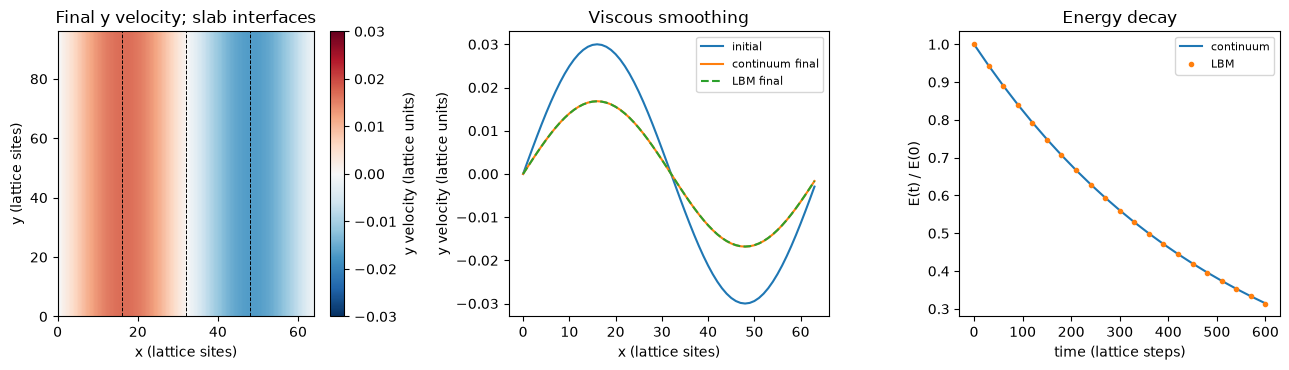

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
image = axes[0].imshow(uy_host.T, origin="lower", extent=(0, NX, 0, NY),
                       cmap="RdBu_r", vmin=-U, vmax=U, aspect="auto")
for boundary in range(NX // mesh.size, NX, NX // mesh.size):
    axes[0].axvline(boundary, color="black", lw=0.7, ls="--")
axes[0].set(xlabel="x (lattice sites)", ylabel="y (lattice sites)",
            title="Final y velocity; slab interfaces")
fig.colorbar(image, ax=axes[0], label="y velocity (lattice units)")
axes[1].plot(np.arange(NX), U * np.sin(K * np.arange(NX)), label="initial")
axes[1].plot(np.arange(NX), expected_uy, label="continuum final")
axes[1].plot(np.arange(NX), uy_host.mean(axis=1), "--", label="LBM final")
axes[1].set(xlabel="x (lattice sites)", ylabel="y velocity (lattice units)",
            title="Viscous smoothing")
axes[1].legend(fontsize=8)
axes[2].plot(sample_times, expected_energy_ratio, label="continuum")
axes[2].plot(sample_times, energy_ratio, ".", label="LBM")
axes[2].set(xlabel="time (lattice steps)", ylabel="E(t) / E(0)", title="Energy decay")
axes[2].legend(fontsize=8)
fig.tight_layout()
plt.show()

## 7. Strong scaling on real GPUs (optional)

Set `RUN_JAX_MULTI_GPU_BENCHMARK=1` before starting Jupyter to enable this section.
Hold the global grid, precision, and number of steps fixed while changing device
count. Input placement happens before timing; each solver is compiled and warmed
up, and every timed result calls `block_until_ready`. Otherwise JAX's asynchronous
dispatch can make Python return well before the GPUs finish.

For elapsed time $T_D$ on $D$ devices, speedup is $S_D=T_1/T_D$, efficiency is
$S_D/D$, and MLUPS is $N_xN_y n/(10^6 T_D)$, where $n$ is the timed step count.
The baseline uses the same halo-aware solver on one device; its ring messages
map back to itself. No plotting, diagnostics, or global reference runs are timed.

The local work falls with slab width, but the message payload per step stays
constant. Strong scaling will eventually saturate. Link topology, message latency,
memory bandwidth, compiler fusion, and local slab width all matter. Two collectives
in the source do not guarantee communication/computation overlap. This array-level
implementation is a teaching baseline; profile before choosing custom kernels.

In [8]:
def benchmark_case(case_devices, nx, ny, *, steps=100, repeats=3):
    if nx % len(case_devices):
        raise ValueError("Grid must divide evenly over devices.")
    case_mesh = Mesh(np.asarray(case_devices), (AXIS,))
    case_sharding = NamedSharding(case_mesh, P(AXIS, None, None))
    _, _, solve = make_distributed_operators(case_mesh)
    with jax.default_device(case_devices[0]):
        initial = shear_initial(nx, ny)
    initial = jax.device_put(initial, case_sharding)
    initial.block_until_ready()
    solve(initial, steps).block_until_ready()
    elapsed = []
    for _ in range(repeats):
        started = time.perf_counter()
        result = solve(initial, steps)
        result.block_until_ready()
        elapsed.append(time.perf_counter() - started)
    return float(np.median(elapsed))


RUN_GPU_BENCHMARK = os.environ.get("RUN_JAX_MULTI_GPU_BENCHMARK", "0") == "1"
if not RUN_GPU_BENCHMARK:
    print("Benchmark disabled; enable with RUN_JAX_MULTI_GPU_BENCHMARK=1.")
elif any(device.platform != "gpu" for device in devices):
    print("Benchmark skipped: real GPUs are required for GPU scaling measurements.")
else:
    BENCH_NX = int(os.environ.get("LBM_BENCH_NX", "1024"))
    BENCH_NY = int(os.environ.get("LBM_BENCH_NY", "1024"))
    if min(BENCH_NX, BENCH_NY) < 2 or BENCH_NX % len(devices):
        raise ValueError("Benchmark dimensions must be >= 2 and NX divisible by device count.")
    counts = [d for d in range(1, len(devices) + 1) if len(devices) % d == 0]
    population_mib = BENCH_NX * BENCH_NY * 9 * np.dtype(DTYPE).itemsize / 2**20
    print(f"Grid {BENCH_NX} x {BENCH_NY}; one global state {population_mib:.1f} MiB")
    print("Allow additional memory for initial/final states and compiler temporaries.")
    scaling = [(d, benchmark_case(devices[:d], BENCH_NX, BENCH_NY)) for d in counts]
    baseline = scaling[0][1]
    print("devices   seconds   speedup   efficiency   MLUPS")
    for d, seconds in scaling:
        speedup = baseline / seconds
        mlups = BENCH_NX * BENCH_NY * 100 / (1e6 * seconds)
        print(f"{d:7d}   {seconds:7.4f}   {speedup:7.2f}   {speedup/d:10.1%}   {mlups:7.1f}")

Benchmark disabled; enable with RUN_JAX_MULTI_GPU_BENCHMARK=1.


## 8. Checks and implementation trade-offs

These checks target the small default case. Conservation tolerances reflect
accumulated floating-point error; the looser physical tolerance includes the
startup transient and finite lattice spacing. Energy is expected to **decrease**:
viscous flow does not conserve kinetic energy. Passing a one-device comparison
alone cannot establish physical correctness.

In [9]:
comparison_tol = 1e-12 if USE_X64 else 2e-6
mass_tol = 1e-10 if USE_X64 else 1e-4
momentum_tol = 1e-12 if USE_X64 else 2e-6
assert reference_error < comparison_tol
assert relative_mass_drift < mass_tol
assert momentum_drift_per_site < momentum_tol
assert energy_curve_error < 0.005
assert velocity_error_relative_to_U < 0.005
assert energy_ratio[-1] < 0.8
assert np.all(np.diff(energy_ratio) < 1e-5)
assert np.isfinite(f_host).all() and np.min(rho_host) > 0
assert f.sharding.spec == P(AXIS, None, None)
print("All routing, reference, conservation, and decay checks passed.")

All routing, reference, conservation, and decay checks passed.


The useful properties of this decomposition are balanced work, strictly local
collision, and small fixed-size neighbour messages. No global population array
is replicated during stepping. The final plotting gather and the single-device
reference are suitable only for small validation runs.

Limitations to anticipate:

- Splitting only $x$ gives thin slabs at large device counts. A two-dimensional
  device grid can reduce the boundary-to-volume ratio, but requires corner
  communication for diagonal populations and more bookkeeping.
- `f[x,y,q]` keeps collision expressions readable. A layout with separate
  population planes may suit a custom coalesced GPU kernel better; packing and
  layout changes should be measured on the target hardware.
- The equilibrium approximation and BGK model are intended for low Mach number
  flow. Small positive viscosity near $\tau=1/2$, high velocities, and
  under-resolved gradients can make this simple model unreliable or unstable.
- Walls would introduce bounce-back and distinguish physical boundaries from
  device interfaces. Multiple nodes require distributed initialization before
  device discovery, identical collective ordering on all processes, and scalable
  checkpointing. Those are separate extensions of this single-node example.

## 9. Optional hands-on block, with complete solutions

**Exercise 1 (10–15 min): diagnose a plausible communication bug.** Predict
what happens if every slab rolls periodically in $x$ without messages. Implement
that change using the starter below. Compare its one-step result with the tagged
NumPy reference. Success means identifying the affected rows and explaining why
mass conservation can still pass. Hint: each local roll is itself a permutation.

**Exercise 2 (15–20 min): predict and measure wavelength dependence.** Double
$N_x$ while keeping $N_y$, $\tau$, $U$, and the final energy ratio fixed. Predict
the required step count before running the reference solution. Success means
explaining the change using the decay law and distinguishing it from a
strong-scaling comparison. Setup and functions are supplied above.

The following cells are reference solutions; try the predictions first.

In [10]:
# Exercise 1 solution: treating each slab as its own periodic domain is incorrect.
@partial(jax.shard_map, mesh=mesh, in_specs=P(AXIS, None, None),
         out_specs=P(AXIS, None, None), axis_names={AXIS})
def broken_stream(f_post):
    return stream_periodic(f_post)


nx_test, ny_test = 3 * mesh.size, 7
tags = np.arange(nx_test * ny_test * 9, dtype=DTYPE).reshape(nx_test, ny_test, 9)
tagged_shards = jax.device_put(tags, f_sharding)
correct_tags = np.asarray(distributed_stream(tagged_shards))
broken_tags = np.asarray(jax.jit(broken_stream)(tagged_shards))
bad_rows = np.flatnonzero(np.any(correct_tags != broken_tags, axis=(1, 2)))
expected_bad_rows = np.sort(np.concatenate((
    np.arange(0, nx_test, 3), np.arange(2, nx_test, 3)
)))
np.testing.assert_array_equal(bad_rows, expected_bad_rows)
assert np.sum(tags, dtype=np.float64) == np.sum(broken_tags, dtype=np.float64)
print(f"Incorrect rows: {bad_rows.tolist()}; total population still conserved.")

Incorrect rows: [0, 2, 3, 5, 6, 8, 9, 11]; total population still conserved.


The first and last row of **every** slab are wrong, including the global periodic
seam. Populations with zero $x$ velocity are unaffected. Each incorrect roll still
preserves the sum of every direction, so even global mass and momentum checks
cannot detect the routing error. The independent tagged test can.

For Exercise 2, doubling $N_x$ halves $k$. The decay rate $\nu k^2$ becomes a
quarter as large, so reaching the same energy ratio takes **four times** as many
steps. The total update count grows by a factor of eight because the site count
also doubles. This changes the global problem, whereas strong scaling keeps it fixed.

In [11]:
# Exercise 2 solution: use distributed reductions, no full-state history or gather.
with jax.default_device(devices[0]):
    doubled_initial = shear_initial(2 * NX, NY)
doubled_initial = jax.device_put(doubled_initial, f_sharding)
doubled_final = distributed_solve(doubled_initial, 4 * N_STEPS)
doubled_ratio = float(distributed_totals(doubled_final)[3]
                      / distributed_totals(doubled_initial)[3])
assert abs(doubled_ratio - energy_ratio[-1]) < 0.005
print(f"Original final E/E0: {energy_ratio[-1]:.6f}")
print(f"Doubled wavelength after four times the steps: {doubled_ratio:.6f}")

Original final E/E0: 0.314048
Doubled wavelength after four times the steps: 0.314436


## References

- JAX: [Manual parallelism with `shard_map`](https://docs.jax.dev/en/latest/notebooks/shard_map.html)
  and [`lax.ppermute`](https://docs.jax.dev/en/latest/_autosummary/jax.lax.ppermute.html).
- JAX: [Benchmarking](https://docs.jax.dev/en/latest/benchmarking.html) and
  [configuration options](https://docs.jax.dev/en/latest/config_options.html).
- Coreixas, Wissocq, Chopard and Latt: [Impact of collision models on the physical
  properties and the stability of lattice Boltzmann methods](https://arxiv.org/abs/2002.05265).
  This explains why the collision model and low Mach assumptions matter when
  extending the minimal example to more demanding flows.